# Exploratory Data Analysis — UCI Credit Card Default

Dataset: [UCI Credit Card Default](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [43]:
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv.zip")
df.drop(columns=['ID'],inplace=True)

In [44]:
X = df.drop(columns=["default.payment.next.month"])


In [45]:
# Load data from /data/raw


df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [46]:
df.shape

(30000, 24)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   30000 non-null

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [49]:
# Check for missing values
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

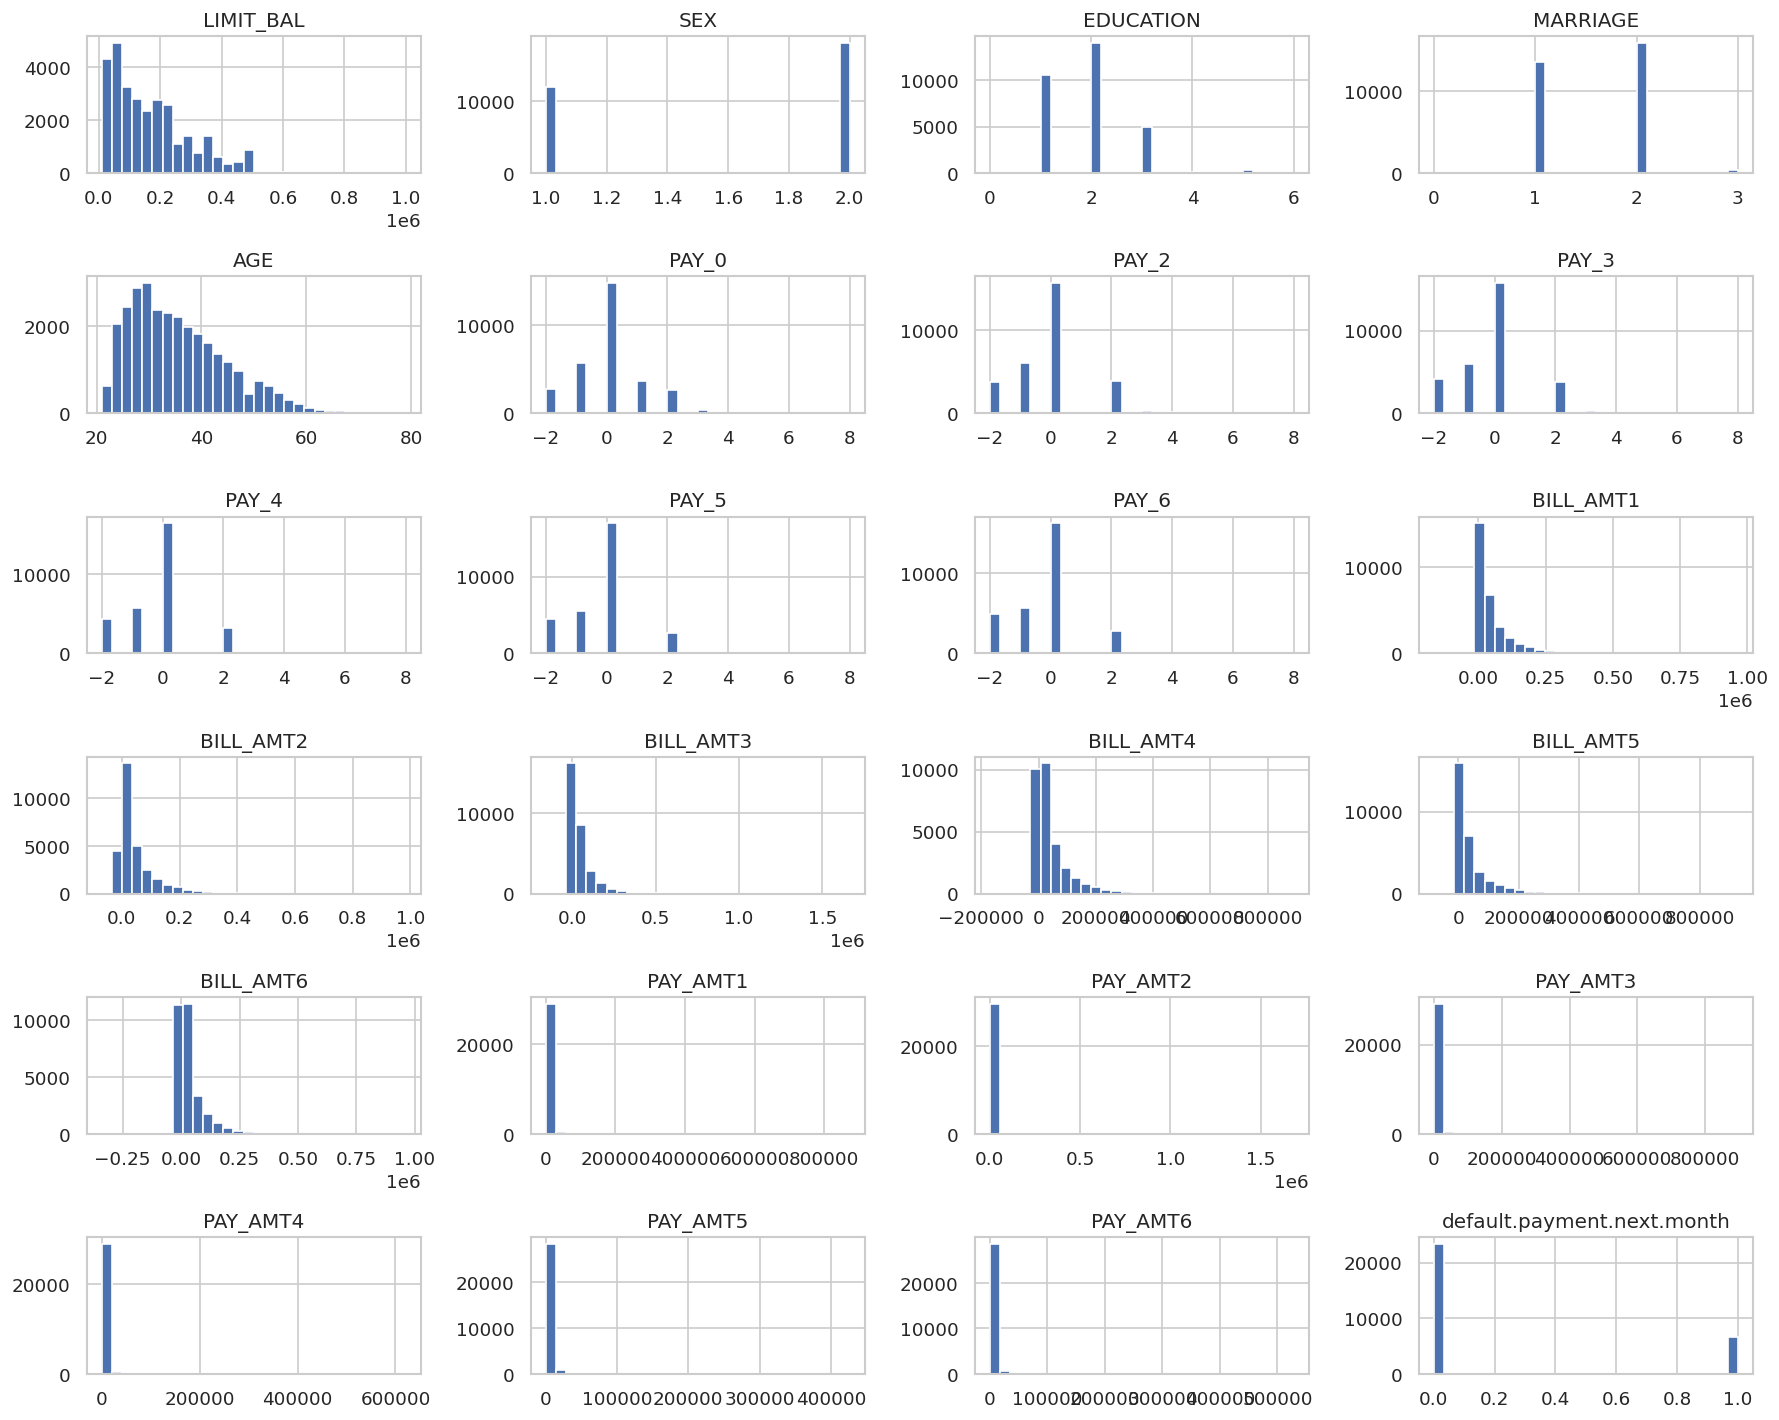

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot all numeric features (adjust columns as needed)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 12), layout=(6, 4))
plt.tight_layout()
plt.show()


In [50]:
# Target distribution
df["default.payment.next.month"].value_counts(normalize=True) # quick way to see if the class is imbalanced

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [51]:
# check input features correlation with target
df.corr()['default.payment.next.month']

LIMIT_BAL                    -0.153520
SEX                          -0.039961
EDUCATION                     0.028006
MARRIAGE                     -0.024339
AGE                           0.013890
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
BILL_AMT1                    -0.019644
BILL_AMT2                    -0.014193
BILL_AMT3                    -0.014076
BILL_AMT4                    -0.010156
BILL_AMT5                    -0.006760
BILL_AMT6                    -0.005372
PAY_AMT1                     -0.072929
PAY_AMT2                     -0.058579
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT5                     -0.055124
PAY_AMT6                     -0.053183
default.payment.next.month    1.000000
Name: default.payment.next.month, dtype: float64

/tmp/ipykernel_490534/3322028944.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


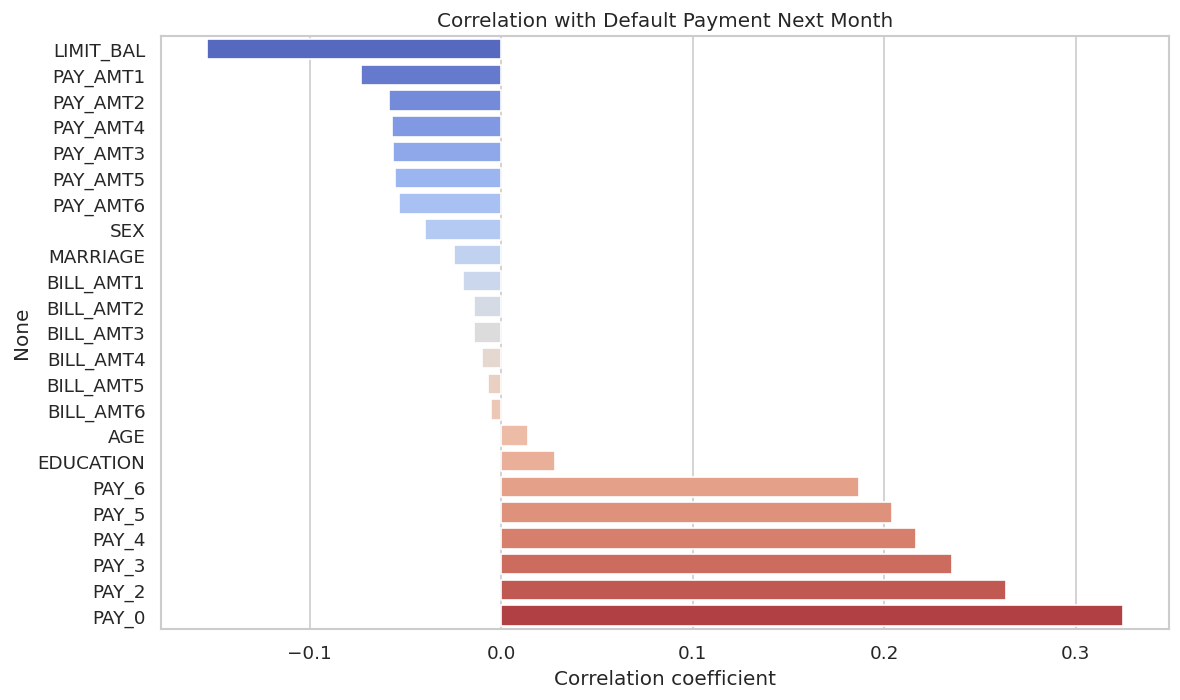

In [52]:
corr_target = df.corr()['default.payment.next.month'].drop('default.payment.next.month')

# Sort for better readability (optional)
corr_target = corr_target.sort_values()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')
plt.title('Correlation with Default Payment Next Month')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

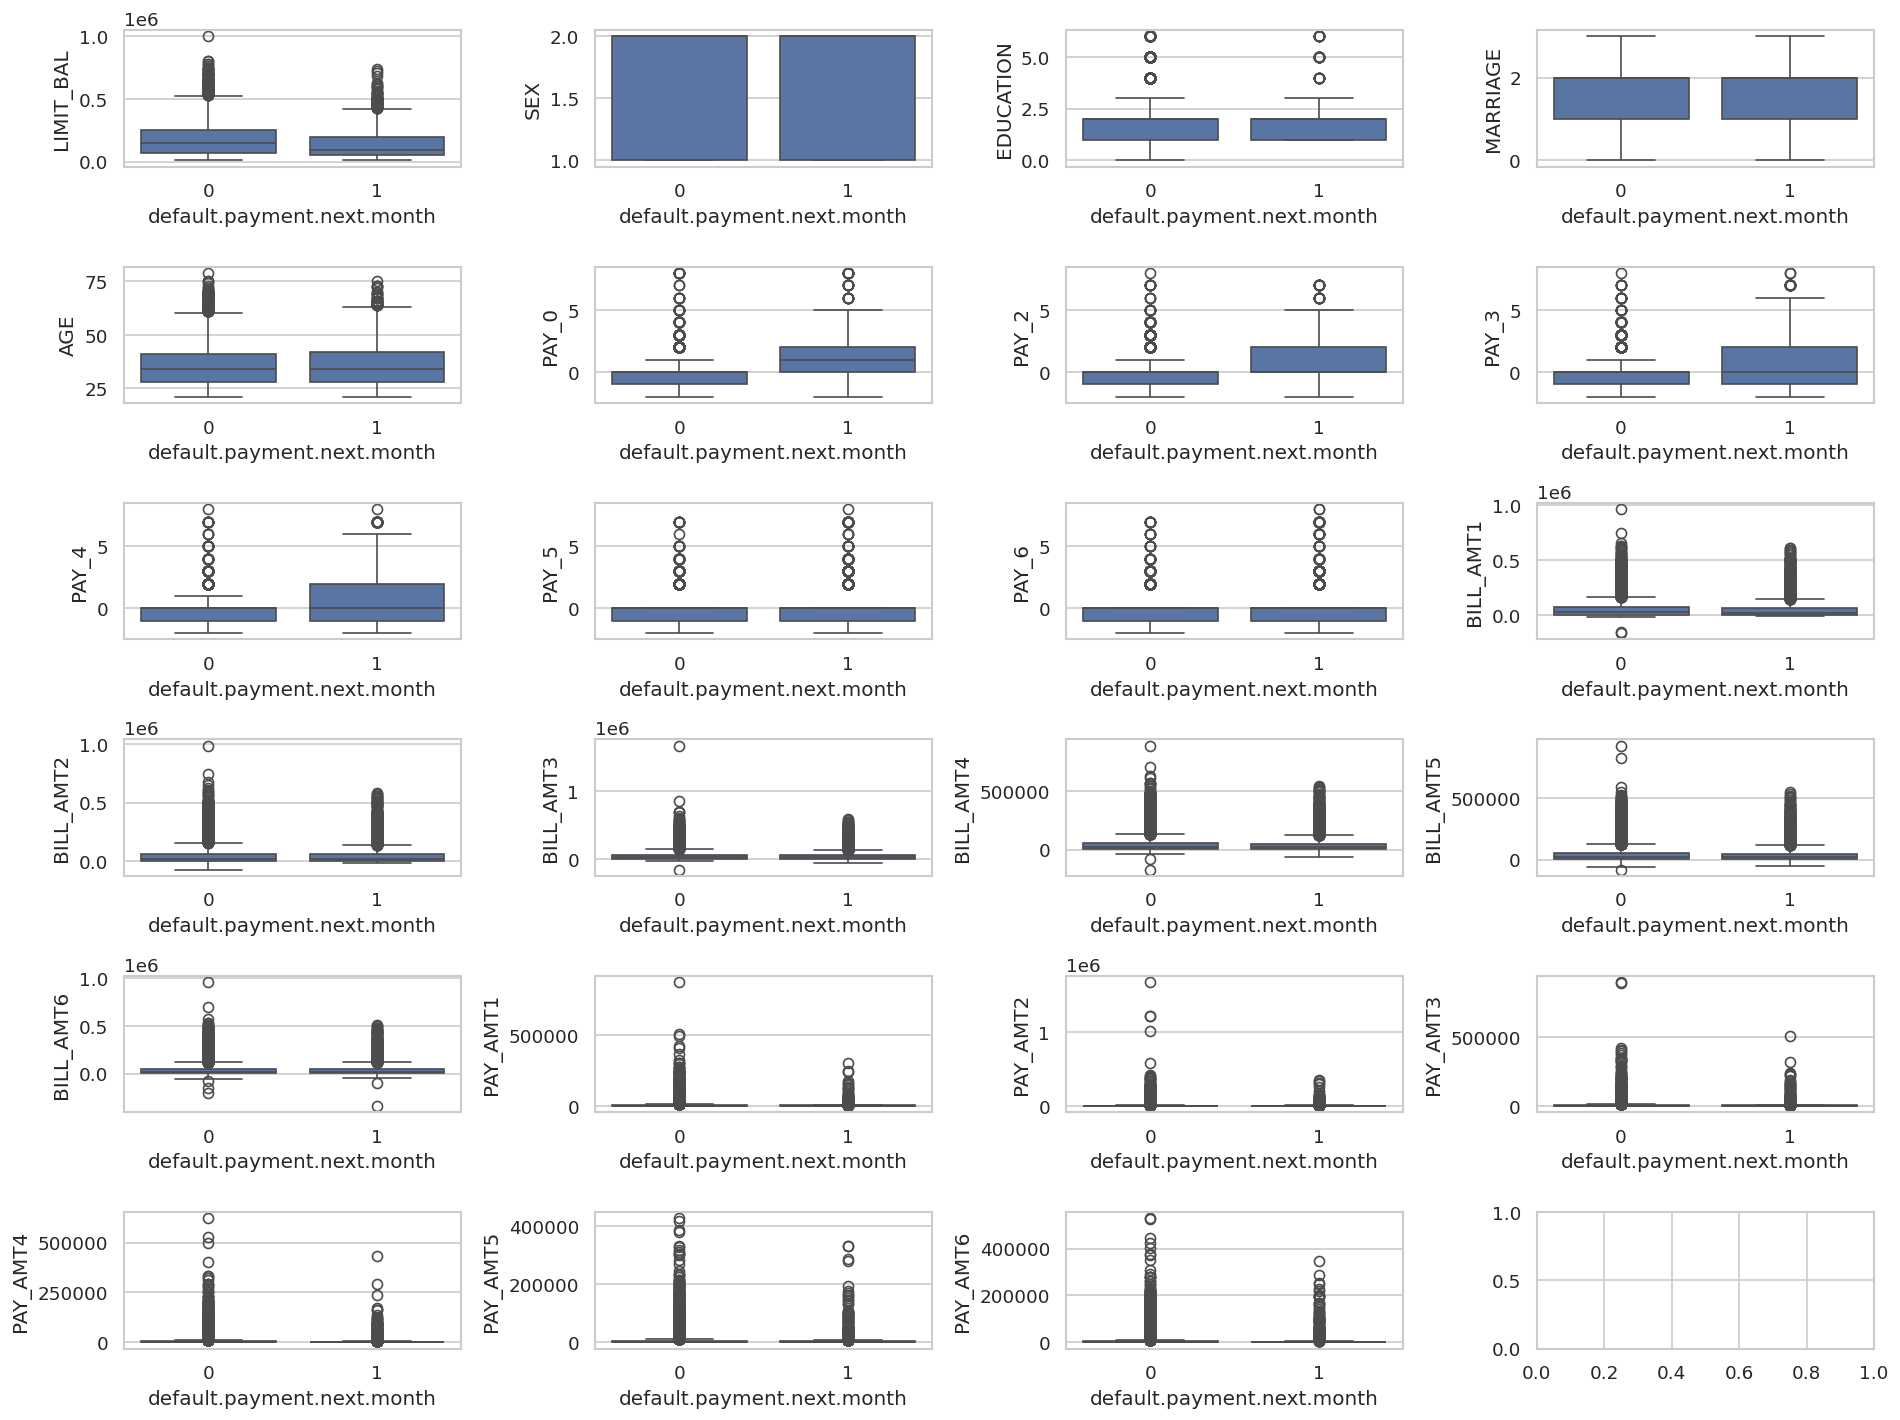

In [53]:
# Boxplots / Violin Plots by Target Class
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 12))  # adjust based on number of features
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(x=df['default.payment.next.month'], y=col, data=df,ax=axes[i])

plt.tight_layout()
plt.show()

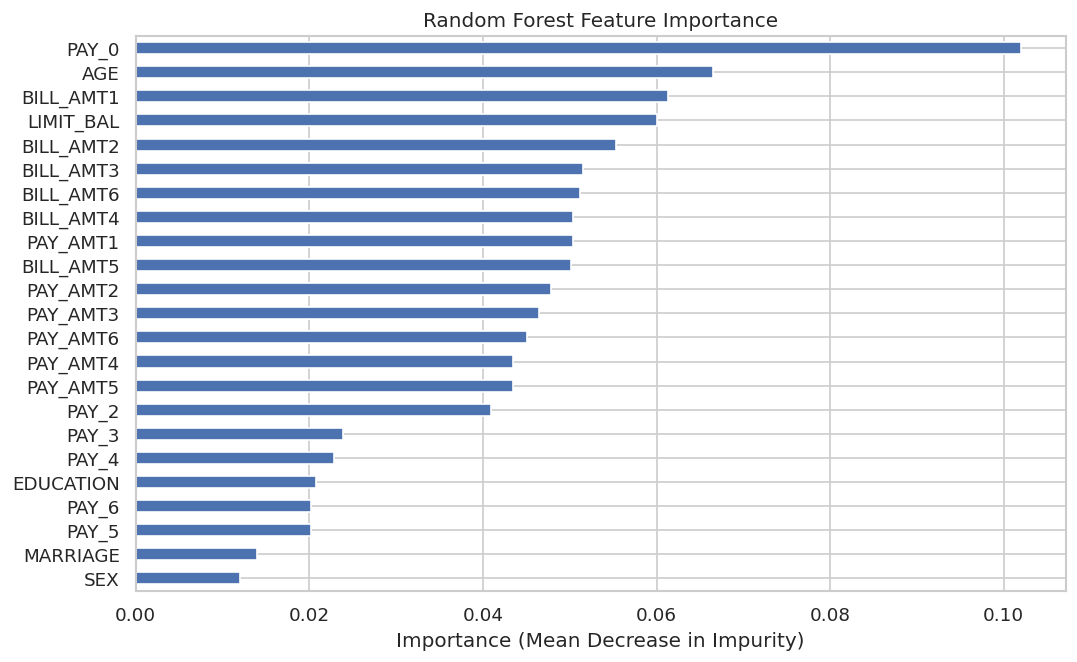

In [54]:
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

# Plot
importances.plot(kind='barh', figsize=(10, 6))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.show()

#### con of Random forest:
##### Random Forest’s feature_importances_ or permutation importance) only tells you how much a feature affects the prediction — not whether higher values make default more or less likely.